# DynBBH Sink-to-AMR Zoom Diagnostics
This notebook runs the same diagnostics as `run_zoom_sink_diagnostics.py`: magnetic divergence, sigma inside the sink/horizon regions, and a final xy slice.

divB max 4.30474134604795e-16
sink sigma first/last mean 1357.237217719608 2.450659464914872e-26
wrote diagnostics in /Users/hengrui/Desktop/research/gr/athenak/analysis/dynbbh_zoom_sink


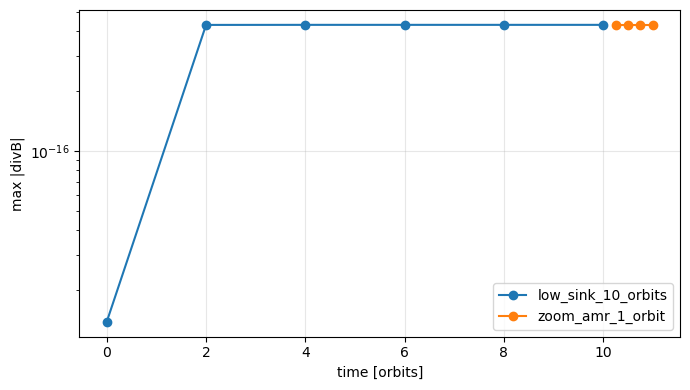

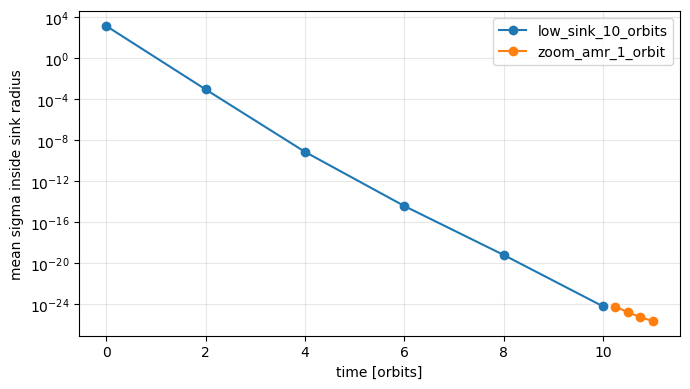

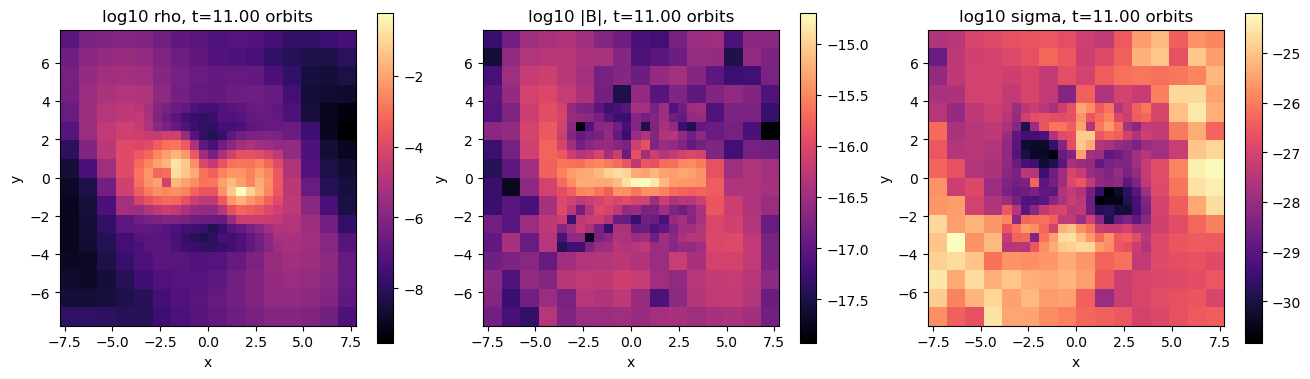

In [1]:
from pathlib import Path
import math
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, '/Users/hengrui/Desktop/research/gr/athenak/scripts')
from plot_tov_ks_binary_slices import read_binary_slice

case_dir = Path('/Users/hengrui/Desktop/research/gr/athenak/analysis/dynbbh_zoom_sink')
runs = [Path('/tmp/dynbbh_zoom_sink_low'), Path('/tmp/dynbbh_zoom_sink_zoom')]
labels = ['low_sink_10_orbits', 'zoom_amr_1_orbit']
table_path = Path('/Users/hengrui/Desktop/research/gr/athenak/analysis/dynbbh_zoom_sink/tilted_spin_sep4_11orbit.dat')
torbit = 50.26548245743669
x3min, x3max = -8.0, 8.0

traj = np.loadtxt(table_path, comments='#')

def interp(col, t):
    return float(np.interp(t, traj[:,0], traj[:,col]))

def interp_vec(cols, t):
    return np.array([interp(c, t) for c in cols])

def z_centers_for(data):
    nz = next(iter(data.variables.values())).shape[0]
    dz = (x3max - x3min)/nz
    return x3min + (np.arange(nz) + 0.5)*dz

def kerr_radius(dx, dy, dz, avec):
    a2 = float(np.dot(avec, avec))
    rr = dx*dx + dy*dy + dz*dz
    if a2 <= 0.0:
        return np.sqrt(rr)
    ahat_dot_x = (avec[0]*dx + avec[1]*dy + avec[2]*dz)/math.sqrt(a2)
    term = rr - a2
    return np.sqrt(0.5*(term + np.sqrt(term*term + 4.0*a2*ahat_dot_x*ahat_dot_x)))

def masks_and_sigma(data):
    x = data.x1v[None, None, :]
    y = data.x2v[None, :, None]
    z = z_centers_for(data)[:, None, None]
    t = data.time
    m1, m2 = interp(1, t), interp(2, t)
    x1, y1, z1 = interp(3, t), interp(4, t), interp(5, t)
    x2, y2, z2 = interp(6, t), interp(7, t), interp(8, t)
    chi1, chi2 = interp_vec([9,10,11], t), interp_vec([12,13,14], t)
    a1, a2 = m1*chi1, m2*chi2
    rH1 = m1 + math.sqrt(max(m1*m1 - float(np.dot(a1, a1)), 0.0))
    rH2 = m2 + math.sqrt(max(m2*m2 - float(np.dot(a2, a2)), 0.0))
    r1 = kerr_radius(x-x1, y-y1, z-z1, a1)
    r2 = kerr_radius(x-x2, y-y2, z-z2, a2)
    mask_h = (r1 <= rH1) | (r2 <= rH2)
    mask_sink = (np.sqrt((x-x1)**2 + (y-y1)**2 + (z-z1)**2) <= 4.0) | (
        np.sqrt((x-x2)**2 + (y-y2)**2 + (z-z2)**2) <= 4.0)
    rho = data.variables['dens']
    b2 = data.variables['bcc1']**2 + data.variables['bcc2']**2 + data.variables['bcc3']**2
    sigma = b2/np.maximum(rho, 1.0e-300)
    return mask_h, mask_sink, sigma

def collect():
    div_rows = []
    sigma_rows = []
    finite_fail = []
    for run, label in zip(runs, labels):
        for path in sorted((run/'bin').glob('torus.mhd_divb.*.bin')):
            d = read_binary_slice(path, ['divb'])
            arr = d.variables['divb']
            if not np.all(np.isfinite(arr)):
                finite_fail.append(str(path))
            div_rows.append([label, d.time/torbit, float(np.nanmax(np.abs(arr))),
                             float(np.sqrt(np.nanmean(arr*arr)))])
        for path in sorted((run/'bin').glob('torus.mhd_w_bcc.*.bin')):
            d = read_binary_slice(path, ['dens','bcc1','bcc2','bcc3'])
            for name, arr in d.variables.items():
                if not np.all(np.isfinite(arr)):
                    finite_fail.append(f'{path}:{name}')
            mask_h, mask_sink, sigma = masks_and_sigma(d)
            for region, mask in [('horizon', mask_h), ('sink_radius', mask_sink)]:
                vals = sigma[mask]
                sigma_rows.append([label, region, d.time/torbit, vals.size,
                                   float(np.nanmean(vals)) if vals.size else np.nan,
                                   float(np.nanmedian(vals)) if vals.size else np.nan,
                                   float(np.nanmax(vals)) if vals.size else np.nan])
    return np.array(div_rows, dtype=object), np.array(sigma_rows, dtype=object), finite_fail

div_rows, sigma_rows, finite_fail = collect()
case_dir.mkdir(parents=True, exist_ok=True)
np.savetxt(case_dir/'zoom_sink_divb_history.csv', div_rows, fmt='%s', delimiter=',',
           header='stage,orbits,max_abs_divb,rms_divb')
np.savetxt(case_dir/'zoom_sink_sigma_history.csv', sigma_rows, fmt='%s', delimiter=',',
           header='stage,region,orbits,ncells,mean,median,max')

fig, ax = plt.subplots(figsize=(7,4))
for label in labels:
    rows = div_rows[div_rows[:,0] == label]
    if rows.size:
        ax.semilogy(rows[:,1].astype(float), rows[:,2].astype(float), 'o-', label=label)
ax.set_xlabel('time [orbits]')
ax.set_ylabel('max |divB|')
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(case_dir/'zoom_sink_divb_history.png', dpi=160)

fig, ax = plt.subplots(figsize=(7,4))
for label in labels:
    rows = sigma_rows[(sigma_rows[:,0] == label) & (sigma_rows[:,1] == 'sink_radius')]
    if rows.size:
        ax.semilogy(rows[:,2].astype(float), rows[:,4].astype(float), 'o-', label=label)
ax.set_xlabel('time [orbits]')
ax.set_ylabel('mean sigma inside sink radius')
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(case_dir/'zoom_sink_sigma_history.png', dpi=160)

mhd_files = sorted((runs[-1]/'bin').glob('torus.mhd_w_bcc.*.bin'))
if mhd_files:
    last = read_binary_slice(mhd_files[-1], ['dens','bcc1','bcc2','bcc3'])
    zv = z_centers_for(last)
    k0 = int(np.argmin(np.abs(zv)))
    rho = last.variables['dens'][k0]
    b2 = last.variables['bcc1'][k0]**2 + last.variables['bcc2'][k0]**2 + last.variables['bcc3'][k0]**2
    sigma = b2/np.maximum(rho, 1.0e-300)
    np.savez(case_dir/'zoom_sink_xy_slice_final.npz', x=last.x1v, y=last.x2v,
             rho=rho, bcc1=last.variables['bcc1'][k0], bcc2=last.variables['bcc2'][k0],
             bcc3=last.variables['bcc3'][k0], sigma=sigma, time=last.time)
    fig, axs = plt.subplots(1, 3, figsize=(13,4), constrained_layout=True)
    extent = [last.x1v[0], last.x1v[-1], last.x2v[0], last.x2v[-1]]
    for ax, arr, title in zip(axs, [rho, np.sqrt(b2), sigma], ['rho', '|B|', 'sigma']):
        im = ax.imshow(np.log10(np.maximum(arr, 1e-300)), origin='lower',
                       extent=extent, cmap='magma')
        ax.set_title(f'log10 {title}, t={last.time/torbit:.2f} orbits')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        fig.colorbar(im, ax=ax, shrink=0.85)
    fig.savefig(case_dir/'zoom_sink_xy_slice_final.png', dpi=180)

if finite_fail:
    raise SystemExit('non-finite diagnostics: ' + '; '.join(finite_fail[:8]))
if div_rows.size and float(np.max(div_rows[:,2].astype(float))) > 1.0e-10:
    raise SystemExit(f'divB exceeded tolerance: {np.max(div_rows[:,2].astype(float)):.3e}')

print('divB max', float(np.max(div_rows[:,2].astype(float))) if div_rows.size else float('nan'))
sink_rows = sigma_rows[sigma_rows[:,1] == 'sink_radius']
if sink_rows.size:
    print('sink sigma first/last mean', float(sink_rows[0,4]), float(sink_rows[-1,4]))
print('wrote diagnostics in', case_dir)
